In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from models import CondSM
from sm import LearnableActivationFunc

print(torch.__version__)

device = 'cuda'    

data_type = 'grad_away_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

def z_score(x, mu, sigma):

    return (x - mu) / sigma

def z_unscore(z, mu, sigma):

    return z * sigma + mu

2.10.0+cu126


In [23]:
input_index = 0
v_min = -1.5
v_max = 1.5

class SimpleFunctionComposition(nn.Module):
    
    def __init__(self, num_components, model, input_index, v_min, v_max, device):
        super().__init__()

        self.device = device
        
        self.num_components = num_components

        self.components_list = nn.ModuleList()

        for i in range(self.num_components):

            self.components_list.append(
                LearnableActivationFunc(
                    model,
                    input_index,
                    v_min,
                    v_max,
                    None,
                    device
                )
            )
            
        self.basis_weights = nn.Parameter(torch.zeros(self.num_components, device=self.device))
        self.gain = nn.Parameter(torch.tensor(1.0))
        self.bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):

        outs = torch.stack([m(x) for m in self.components_list], dim=0)

        y = torch.einsum('i, ibk->bk', self.basis_weights, outs)
        
        return self.gain * y + self.bias

y_mean: -0.03067497246978625 | y_std: 1.276240995672341


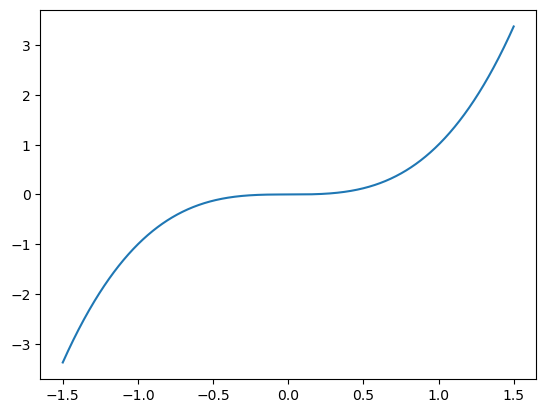

In [32]:
comp = SimpleFunctionComposition(10, model, input_index, -1.5, 1.5, device)
comp = comp.to(device)

#print(comp.components_list[0].raw_cntrl_params)
#print(comp.components_list[0].scale_cntrl())
#print(comp.components_list[0].raw_cntrl_params)

X = np.linspace(-1.5, 1.5, 1024)
y = X**3#np.cos(4.0*X) + np.exp(0.5*X**2) + np.random.normal(loc=0.0, scale=0.05)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

train_target_mu, train_target_sigma = y_train.mean(), y_train.std()
print(f'y_mean: {train_target_mu} | y_std: {train_target_sigma}')

train_x = torch.from_numpy(X_train).unsqueeze(-1).float()
test_x = torch.from_numpy(X_test).unsqueeze(-1).float()
train_y = torch.from_numpy(y_train).unsqueeze(-1).float()
test_y = torch.from_numpy(y_test).unsqueeze(-1).float()  

train_set = TensorDataset(train_x, train_y)
test_set = TensorDataset(test_x, test_y)

batch_size = 128
train_loader = DataLoader(train_set, batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size, shuffle=False)

plt.plot(X, y)

In [10]:
with torch.no_grad():
    xs = torch.linspace(-1.5, 1.5, 200, device=device).unsqueeze(-1)
    y0 = comp.components_list[0](xs)   # first basis curve
    # Check variance/shape:
    print('var(y0):', y0.var().item())

var(y0): 0.0021460531279444695


In [34]:
epochs = 200
PRINT_EVERY = 10

#optimizer = torch.optim.SGD((p for p in comp.parameters() if p.requires_grad), lr=1e-2, momentum=0.9)
optimizer = torch.optim.Adam((p for p in comp.parameters() if p.requires_grad), lr=1e-2)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=epochs, eta_min=1e-2)

loss_fn = torch.nn.MSELoss()

for epoch in range(1, epochs+1):
    train_loss = 0.0
    comp.train()
    for x, y in train_loader:
        
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        pred = comp(x)

        #loss = loss_fn(pred, y)
        loss = loss_fn(z_score(pred, train_target_mu, train_target_sigma), z_score(y, train_target_mu, train_target_sigma))
        loss.backward()
        #print('||grad(raw_cntrl_params)|| =', comp.components_list[0].raw_cntrl_params.grad.norm().item())
        #print('||grad(basis_weights)|| =', comp.ba sis_weights.grad.norm().item())

        optimizer.step()

        train_loss += loss.item() * x.size(0)

    comp.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            
            x, y = x.to(device), y.to(device)

            pred = comp(x)
            
            #loss = loss_fn(pred, y)
            loss = loss_fn(z_score(pred, train_target_mu, train_target_sigma), z_score(y, train_target_mu, train_target_sigma))
    
            test_loss += loss.item() * x.size(0)

    if epoch % PRINT_EVERY == 0:
            print(f'[{epoch}/{epochs}] | Train Loss: {train_loss / len(train_loader.dataset)} | Test Loss: {test_loss / len(test_loader.dataset)} | LR: {scheduler.optimizer.param_groups[0]["lr"]}')
    
    #scheduler.step()

[10/200] | Train Loss: 0.3729154302014245 | Test Loss: 0.3305002570152283 | LR: 0.01
[20/200] | Train Loss: 0.2332957821451264 | Test Loss: 0.21275035375502052 | LR: 0.01
[30/200] | Train Loss: 0.2104540062620235 | Test Loss: 0.1927671122114833 | LR: 0.01
[40/200] | Train Loss: 0.20447531435297522 | Test Loss: 0.1862700210838783 | LR: 0.01
[50/200] | Train Loss: 0.19923627869622904 | Test Loss: 0.18122716713242415 | LR: 0.01
[60/200] | Train Loss: 0.19634547780503284 | Test Loss: 0.17950519214316113 | LR: 0.01
[70/200] | Train Loss: 0.19306781278497862 | Test Loss: 0.17648838053389293 | LR: 0.01
[80/200] | Train Loss: 0.1899369563884642 | Test Loss: 0.17437238780463615 | LR: 0.01
[90/200] | Train Loss: 0.1853649901710587 | Test Loss: 0.16862546001992573 | LR: 0.01
[100/200] | Train Loss: 0.17963800147193984 | Test Loss: 0.16235026055719795 | LR: 0.01
[110/200] | Train Loss: 0.16927366812005 | Test Loss: 0.1550295130508702 | LR: 0.01
[120/200] | Train Loss: 0.15848834960015265 | Test Lo

In [12]:
#for n, p in comp.named_parameters():
#    print(n, p.requires_grad, p.shape)

# measure the surrogate's local sensitivity to each input dim at your current point
def input_sensitivities(sm, z):
    z = z.clone().requires_grad_(True)
    u = sm(z).sum()
    (du_dz,) = torch.autograd.grad(u, z, create_graph=False)
    return du_dz.detach()

# build one batch-point exactly like in your forward
with torch.no_grad():
    B = 1
    cntrl = comp.components_list[0].scale_cntrl()[None,:]  # (1, D-1)
    left  = cntrl[:, :input_index]
    right = cntrl[:, input_index:]
    x_in  = torch.tensor([[0.0]], device=cntrl.device)      # pick any x
    x_sc  = comp.components_list[0].affine_input_scaling(x_in)
    z     = torch.cat([left, x_sc, right], dim=1)           # shape (1, D)

# now get ∂out/∂z_j
du_dz = input_sensitivities(comp.components_list[0].sm, z)  # (1, D)
print('per-dim |∂out/∂z_j|:', du_dz.abs().cpu().numpy())

per-dim |∂out/∂z_j|: [[0.09065987 0.13841099 0.00827328 0.05322989 0.01367303 0.10460603
  1.5535727 ]]


Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0',
       requires_grad=True)


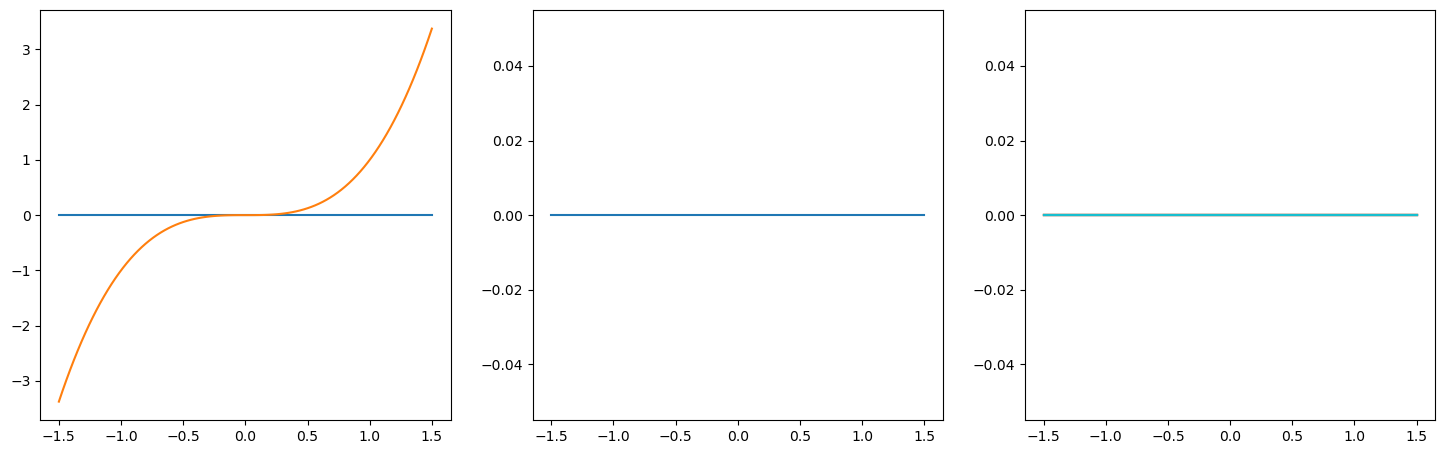

In [33]:
m = nn.ReLU()
x = torch.linspace(-1.5, 1.5, 100)

comp.eval()
x_input = torch.linspace(-1.5, 1.5, 100).unsqueeze(1).to(device)
with torch.no_grad():
    out = comp(x_input).detach().cpu()

fig, ax = plt.subplots(ncols=3, figsize=(18, 6))
for a in ax:
    a.set_box_aspect(1)
ax[0].plot(x, out)
t = x**3#np.cos(4*x) + np.exp(0.5*x**2)
ax[0].plot(x, t)

print(comp.basis_weights)

out_sum = 0
for i in range(comp.num_components):
    
    with torch.no_grad():
        out = (comp.basis_weights[i] * comp.components_list[i](x_input)).detach().cpu()

    ax[2].plot(x, (comp.gain.detach().cpu() * out + comp.bias.detach().cpu()))
    out_sum += out
ax[1].plot(x, out_sum)

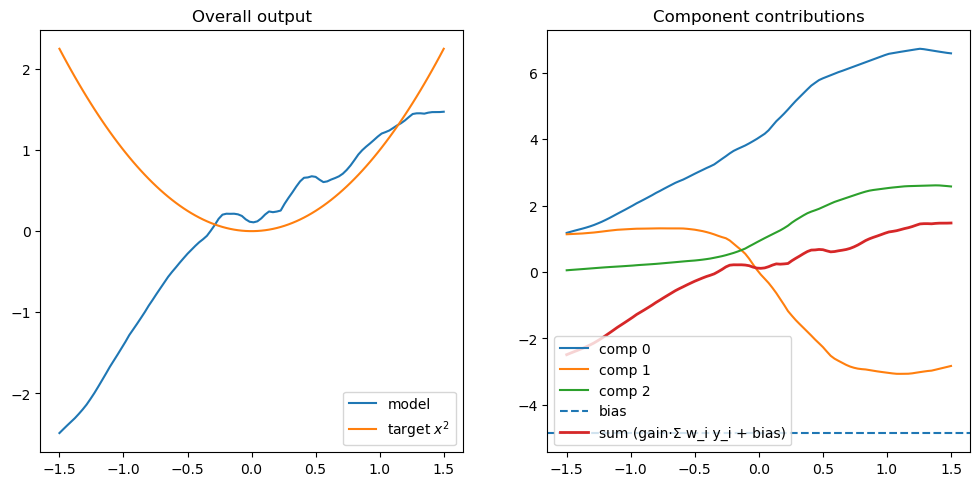

In [8]:
comp.eval()

x = torch.linspace(-1.5, 1.5, 100)
x_input = x.unsqueeze(1).to(device)

with torch.no_grad():
    # overall model output
    y_pred = comp(x_input).squeeze(1).cpu()

    # raw basis outputs stacked: [C, B]
    basis_outs = torch.stack(
        [m(x_input).squeeze(1).cpu() for m in comp.components_list], dim=0
    )  # (C, B)

    # weights and gain/bias on cpu
    w     = comp.basis_weights.detach().cpu()         # (C,)
    gain  = getattr(comp, "gain", torch.tensor(1.0)).detach().cpu()
    bias  = getattr(comp, "bias", torch.tensor(0.0)).detach().cpu()

    # linear mix (pre gain/bias) and full mix (post gain/bias)
    y_lin  = (w[:, None] * basis_outs).sum(0)         # (B,)
    y_full = gain * y_lin + bias                      # (B,)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
for a in ax:
    a.set_box_aspect(1)

# Left: overall fit vs target
ax[0].plot(x.cpu(), y_pred, label="model")
ax[0].plot(x.cpu(), (x**2).cpu(), label="target $x^2$")
ax[0].legend()
ax[0].set_title("Overall output")

# Right: per-component contributions (after gain), and bias
for i in range(comp.num_components):
    contrib_i = gain * w[i] * basis_outs[i]           # (B,)
    ax[1].plot(x.cpu(), contrib_i, label=f"comp {i}")

# Optional: show bias as a horizontal line
if bias.abs().item() > 0:
    ax[1].axhline(bias.item(), linestyle="--", label="bias")

# And the summed curve for reference
ax[1].plot(x.cpu(), y_full, linewidth=2, label="sum (gain·Σ w_i y_i + bias)")
ax[1].legend()
ax[1].set_title("Component contributions")
plt.show()
